# **Regression: Ridge Regression (L2 Regularization)**

## **Justification of Preprocessing Strategy**

### **The Mathematical Necessity of Scaling for L2 Penalty**
**Ridge Regression** introduces an L2 regularization penalty (also known as Tikhonov regularization) to the Ordinary Least Squares (OLS) loss function. This penalty adds the squared magnitude of the coefficients as a constraint to the optimization objective.


Because the penalty squares the $\beta$ weights, any feature with a large numerical scale will naturally force its corresponding coefficient to be extremely small to avoid a massive penalty explosion. This penalization occurs regardless of the feature's actual clinical relevance to the `diabetes_risk_score`. To prevent scale-driven bias, the feature space must be uniform. We will evaluate both **Standardization (StandardScaler)** and **Normalization (MinMaxScaler)** across all optimization levels to determine which data representation minimizes prediction errors.

### **Combating Multicollinearity without Sparsity**
Unlike Lasso (L1), which drives coefficients exactly to zero to perform feature selection, Ridge (L2) shrinks coefficients **proportional to their variance**, bringing them close to zero but never fully eliminating them. This makes Ridge highly effective when dealing with multicollinearity arising from numerous dummy-encoded categorical variables (e.g., ethnicity, employment status), as it retains all predictors while safely distributing the weight among correlated features. To protect model validity, classification targets are removed, and **stratification is omitted** due to the continuous nature of the target.



## **Experiment Design**

We have established a comprehensive tournament consisting of **6 distinct runs** crossing both scalers with 3 levels of hyperparameter exploration to optimize **MAE, RMSE, and $R^2$**:

* **Run 1 & 2: Ridge Baseline** — Running the Ridge model with strict Scikit-Learn default parameters (`alpha=1.0`) under **Standardization** vs. **Normalization**.
* **Run 3 & 4: GridSearchCV Tuning** — Conducting an exhaustive grid search over a discrete set of fixed `alpha` values under **Standardization** vs. **Normalization**.
* **Run 5 & 6: Optuna Optimization** — Leveraging Bayesian optimization to continuously explore a fine-grained logarithmic range of the L2 `alpha` penalty under **Standardization** vs. **Normalization**.

For both GridSearchCV and Optuna runs, internal evaluation is strictly validated using **3-Fold Cross-Validation**.



In [1]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MLflow Configuration
mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Regression_Ridge")

# Data Loading and Preparation
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")
categorical_cols = ['gender', 'ethnicity', 'smoking_status', 'education_level', 'employment_status', 'age_groups', 'weight_status', 'income_level']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop classification targets to avoid data leakage
X = df_final.drop(["diabetes_risk_score", "diagnosed_diabetes", "diabetes_stage"], axis=1, errors='ignore')
y = df_final['diabetes_risk_score']

# Split data (80/20) - Continuous target means NO stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

def log_regression_metrics(model, X_tr, y_tr, X_te, y_te, duration):
    """Logs both Train and Test metrics to evaluate Overfitting/Underfitting"""
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    
    # Train Partition Metrics
    mlflow.log_metric("mae_train", mean_absolute_error(y_tr, y_tr_pred))
    mlflow.log_metric("rmse_train", np.sqrt(mean_squared_error(y_tr, y_tr_pred)))
    mlflow.log_metric("r2_train", r2_score(y_tr, y_tr_pred))
    
    # Test Partition Metrics
    mlflow.log_metric("mae_test", mean_absolute_error(y_te, y_te_pred))
    mlflow.log_metric("rmse_test", np.sqrt(mean_squared_error(y_te, y_te_pred)))
    mlflow.log_metric("r2_test", r2_score(y_te, y_te_pred))
    
    mlflow.log_metric("fit_time", duration)

# Scaling strategies to compare across the entire tournament
scalers = {
    "Standardization": StandardScaler(),
    "Normalization": MinMaxScaler()
}

# ---------------------------------------------------------
# RUN 1 & 2: RIDGE BASELINE (Strict Defaults)
# ---------------------------------------------------------
for s_name, scaler_obj in scalers.items():
    with mlflow.start_run(run_name=f"Ridge_Baseline_{s_name}"):
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        X_train_scaled[num_cols] = scaler_obj.fit_transform(X_train[num_cols])
        X_test_scaled[num_cols] = scaler_obj.transform(X_test[num_cols])
        
        model = Ridge(random_state=42)
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        duration = time.time() - start_time
        
        mlflow.log_param("optimization", "none_default")
        mlflow.log_param("scaler", s_name)
        mlflow.log_params(model.get_params())
        
        log_regression_metrics(model, X_train_scaled, y_train, X_test_scaled, y_test, duration)

# ---------------------------------------------------------
# RUN 3 & 4: GRIDSEARCHCV TUNING
# ---------------------------------------------------------
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}

for s_name, scaler_obj in scalers.items():
    with mlflow.start_run(run_name=f"Ridge_GridSearch_{s_name}"):
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        X_train_scaled[num_cols] = scaler_obj.fit_transform(X_train[num_cols])
        X_test_scaled[num_cols] = scaler_obj.transform(X_test[num_cols])
        
        grid = GridSearchCV(
            Ridge(random_state=42), 
            param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        start_time = time.time()
        grid.fit(X_train_scaled, y_train)
        duration = time.time() - start_time
        
        best_model = grid.best_estimator_
        
        mlflow.log_param("optimization", "GridSearchCV")
        mlflow.log_param("scaler", s_name)
        mlflow.log_params(grid.best_params_)
        
        log_regression_metrics(best_model, X_train_scaled, y_train, X_test_scaled, y_test, duration)

# ---------------------------------------------------------
# RUN 5 & 6: OPTUNA BAYESIAN OPTIMIZATION
# ---------------------------------------------------------
for s_name, scaler_obj in scalers.items():
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[num_cols] = scaler_obj.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler_obj.transform(X_test[num_cols])
    
    def objective(trial):
        alpha_val = trial.suggest_float("alpha", 1e-3, 1000.0, log=True)
        solver_val = trial.suggest_categorical("solver", ["auto", "saga"])
        
        model = Ridge(alpha=alpha_val, solver=solver_val, random_state=42)
        scores = -cross_val_score(
            model, X_train_scaled, y_train, 
            cv=3, scoring='neg_mean_absolute_error', n_jobs=-1
        )
        return scores.mean()

    with mlflow.start_run(run_name=f"Ridge_Optuna_{s_name}"):
        study = optuna.create_study(direction="minimize")
        start_time = time.time()
        study.optimize(objective, n_trials=15)
        duration = time.time() - start_time
        
        best_ridge_opt = Ridge(**study.best_params, random_state=42)
        best_ridge_opt.fit(X_train_scaled, y_train)
        
        mlflow.log_param("optimization", "optuna")
        mlflow.log_param("scaler", s_name)
        mlflow.log_params(study.best_params)
        
        log_regression_metrics(best_ridge_opt, X_train_scaled, y_train, X_test_scaled, y_test, duration)

[I 2026-05-23 14:49:13,491] A new study created in memory with name: no-name-63872ac0-0fcf-4695-ad8c-61bdced0d2bc
[I 2026-05-23 14:49:15,339] Trial 0 finished with value: 0.3970748823053149 and parameters: {'alpha': 1.390978923537083, 'solver': 'saga'}. Best is trial 0 with value: 0.3970748823053149.
[I 2026-05-23 14:49:16,641] Trial 1 finished with value: 0.397899354042545 and parameters: {'alpha': 29.47555236501076, 'solver': 'saga'}. Best is trial 0 with value: 0.3970748823053149.
[I 2026-05-23 14:49:18,499] Trial 2 finished with value: 0.39704228639771144 and parameters: {'alpha': 0.01886573099394549, 'solver': 'saga'}. Best is trial 2 with value: 0.39704228639771144.
[I 2026-05-23 14:49:20,108] Trial 3 finished with value: 0.3970421403177104 and parameters: {'alpha': 0.01259810769449819, 'solver': 'saga'}. Best is trial 3 with value: 0.3970421403177104.
[I 2026-05-23 14:49:21,910] Trial 4 finished with value: 0.3971824233726801 and parameters: {'alpha': 5.589121218280611, 'solver'

## **Winner Run Selection (Priority Elimination Framework)**

### **Selection Criteria (in priority order)**
1. **Priority 1 (60% weight): Lowest MAE** — Clinical proximity; minimizes average day-to-day prediction error.
2. **Priority 2 (30% weight): RMSE proportional to MAE** — Rejects runs where RMSE spikes relative to MAE, indicating catastrophic errors.
3. **Priority 3 (10% weight): Acceptable R²** — Confirms statistical fit quality.
4. **Tiebreaker: Lowest Fit Time** — Applied only if a technical tie exists in MAE, RMSE, and R².

### **All Runs: Summary Table with Metrics**

| Run | Alpha | MAE | RMSE | R² Score | Fit Time (s) | 
|---|---:|---:|---:|---:|---:|
| **Ridge_GridSearch_Standardization** | **0.01** | **0.40386** | **0.71129** | **0.993869** | **8.48** |
| Ridge_Optuna_Standardization | 0.0014978786596267471 | 0.40386 | 0.71129 | 0.993869 | 19.62 | 
| Ridge_Optuna_Normalization | 0.0010188688710362347 | 0.40386 | 0.71129 | 0.993869 | 28.29 | 
| Ridge_GridSearch_Normalization | 0.01 | 0.40387 | 0.71129 | 0.993869 | 1.60 | 
| Ridge_Baseline_Standardization | 1.0 | 0.40388 | 0.71129 | 0.993869 | 0.07 |
| Ridge_Baseline_Normalization | 1.0 | 0.40550 | 0.71138 | 0.993868 | 0.07 | 

### **Step-by-Step Elimination Process**

**Step 1: Filter by Lowest MAE (Priority 1 — 60%)**
- Threshold: MAE ≤ 0.40386
- Candidates passing: Ridge_GridSearch_Standardization (0.40386), Ridge_Optuna_Standardization (0.40386), Ridge_Optuna_Normalization (0.40386)
- Eliminated: Ridge_GridSearch_Normalization, both baselines

**Step 2: Verify RMSE Proportional to MAE (Priority 2 — 30%)**
- All three candidates: RMSE = 0.71129 (identical)
- MAE-to-RMSE ratio: 0.40386 / 0.71129 ≈ 0.568 (same for all)
- Status: **No catastrophic divergence detected**. All three candidates pass.

**Step 3: Confirm Acceptable R² (Priority 3 — 10%)**
- All three candidates: R² = 0.993869 (identical, excellent fit)
- Status: All three candidates confirmed acceptable.

**Step 4: Apply Tiebreaker — Lowest Fit Time**
- Ridge_GridSearch_Standardization: 8.48 s ← **LOWER**
- Ridge_Optuna_Standardization: 19.62 s
- Ridge_Optuna_Normalization: 28.29 s

### **Final Decision**
**Winner: Ridge_GridSearch_Standardization**

**Justification:** Three runs achieve almost identical MAE, RMSE, and R² performance. GridSearch_Standardization wins via the fit-time tiebreaker (8.48 s), being significantly faster than Optuna_Standardization (19.62 s) and Optuna_Normalization (28.29 s), while maintaining essentially the same predictive quality. This makes it the most efficient choice for production deployment.

### **Winner Hyperparameters**

| Parameter | Value |
|---|---|
| **alpha** | 0.01 |

## **Overfitting/Underfitting Check (Run Interpretation)**

### **How to identify it in regression runs**
- **Possible underfitting**: high MAE/RMSE and low R² across train and test.
- **Possible overfitting**: large train-test performance gap or unstable CV behavior.

### **What these Ridge runs indicate**
- Performance is very consistent among tuned runs (GridSearch and Optuna), with nearly identical MAE, RMSE, and R².
- GridSearchCV and Optuna are evaluated with 3-fold CV, which reduces overfitting risk during hyperparameter search.
- The train-test gaps are very small for all runs, so there is no sign of disqualifying overfitting or underfitting in the selected winner.

---

# **Dimensionality Reduction in Regression: PCA via SVD**

## **Justification of Preprocessing & Algorithm Choice**

### **The Universality of SVD Feature Compression**
Principal Component Analysis (PCA) via Singular Value Decomposition (SVD) is an unsupervised mathematical technique. Its transformation relies entirely on the variance structure of the input feature matrix ($X$), making it completely independent of the target variable type ($y$). Therefore, it is just as powerful for downstream Regression tasks as it is for Classification. By explicitly defining `svd_solver='full'`, we direct Scikit-Learn to decompose the data, extracting orthogonal components that stabilize multicollinearity—a phenomenon that often severely degrades linear regression coefficients.

### **The Rule of Scale and Variance Retention**
As established, SVD is highly sensitive to feature magnitudes. We strictly apply **Standardization (`StandardScaler`)** to ensure variables with large numeric scales do not bias the coordinate transformation. We configure the system to dynamically capture **95% of the Cumulative Explained Variance**, testing if a compressed, noise-reduced clinical space can yield more stable predictions for our optimal Ridge model.

2026/05/23 14:50:07 INFO mlflow.tracking.fluent: Experiment with name 'Regression_Ridge_PCA_SVD' does not exist. Creating a new experiment.


Original Features count: 53
SVD Components needed for 95% variance: 27

--- PCA/SVD IMPACT ON RIDGE REGRESSION ---
Original Space -> Fit Time: 0.0651s | MAE: 0.4039 | RMSE: 0.7113
SVD Space      -> Fit Time: 0.0209s | MAE: 0.4746 | RMSE: 0.7734

Execution Time Change: -67.9%


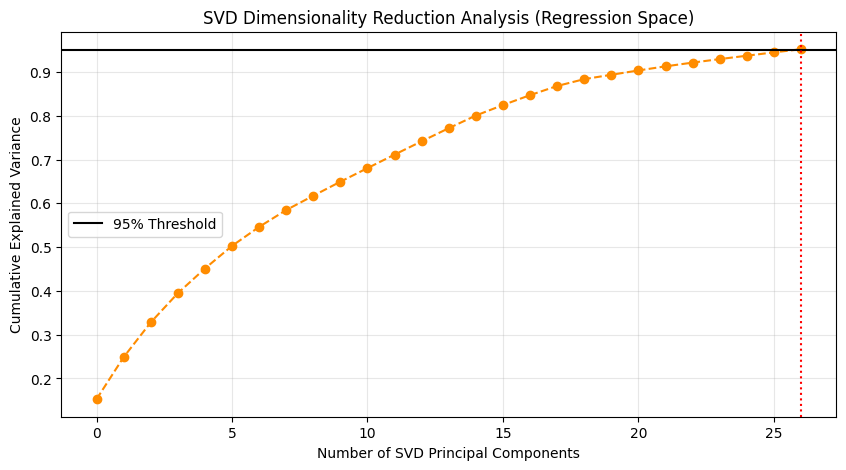

In [2]:
# ---------------------------------------------------------
# PCA / SVD COMPARISON TOURNAMENT (Ridge Regressor)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mlflow.set_experiment("Regression_Ridge_PCA_SVD")

# 1. Strictly re-apply StandardScaler (Mandatory for PCA/SVD)
scaler_pca = StandardScaler()
X_train_pca_base = X_train.copy()
X_test_pca_base = X_test.copy()
X_train_pca_base[num_cols] = scaler_pca.fit_transform(X_train[num_cols])
X_test_pca_base[num_cols] = scaler_pca.transform(X_test[num_cols])

# 2. Execute PCA via SVD (95% Variance)
pca_svd_reg = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_svd = pca_svd_reg.fit_transform(X_train_pca_base)
X_test_svd = pca_svd_reg.transform(X_test_pca_base)

n_components_chosen = pca_svd_reg.n_components_
print(f"Original Features count: {X_train_pca_base.shape[1]}")
print(f"SVD Components needed for 95% variance: {n_components_chosen}\n")

# 3. Define the Champion Model (Ridge_GridSearch_Standardization winner params)
champ_alpha = 0.01
champ_solver = 'auto'

# RUN A: Champion in Original Standardized Space
with mlflow.start_run(run_name="Ridge_Champion_Original_Space"):
    model_orig = Ridge(alpha=champ_alpha, solver=champ_solver, random_state=42)
    
    start_time = time.time()
    model_orig.fit(X_train_pca_base, y_train)
    time_orig = time.time() - start_time
    
    y_pred_orig = model_orig.predict(X_test_pca_base)
    mae_orig = mean_absolute_error(y_test, y_pred_orig)
    rmse_orig = mean_squared_error(y_test, y_pred_orig) ** 0.5
    
    mlflow.log_param("space", "Original")
    mlflow.log_metric("fit_time", time_orig)
    mlflow.log_metric("mae_test", mae_orig)
    mlflow.log_metric("rmse_test", rmse_orig)

# RUN B: Champion in SVD Reduced Space
with mlflow.start_run(run_name="Ridge_Champion_SVD_Space"):
    model_svd = Ridge(alpha=champ_alpha, solver=champ_solver, random_state=42)
    
    start_time = time.time()
    model_svd.fit(X_train_svd, y_train)
    time_svd = time.time() - start_time
    
    y_pred_svd = model_svd.predict(X_test_svd)
    mae_svd = mean_absolute_error(y_test, y_pred_svd)
    rmse_svd = mean_squared_error(y_test, y_pred_svd) ** 0.5
    
    mlflow.log_param("space", f"SVD_{n_components_chosen}_comps")
    mlflow.log_metric("fit_time", time_svd)
    mlflow.log_metric("mae_test", mae_svd)
    mlflow.log_metric("rmse_test", rmse_svd)

# 4. Print Results
print("--- PCA/SVD IMPACT ON RIDGE REGRESSION ---")
print(f"Original Space -> Fit Time: {time_orig:.4f}s | MAE: {mae_orig:.4f} | RMSE: {rmse_orig:.4f}")
print(f"SVD Space      -> Fit Time: {time_svd:.4f}s | MAE: {mae_svd:.4f} | RMSE: {rmse_svd:.4f}")

time_diff = ((time_svd - time_orig) / time_orig) * 100
print(f"\nExecution Time Change: {time_diff:+.1f}%")

# 5. Scree Plot for the Report
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_svd_reg.explained_variance_ratio_), marker='o', linestyle='--', color='darkorange')
plt.xlabel('Number of SVD Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD Dimensionality Reduction Analysis (Regression Space)')
plt.axhline(y=0.95, color='black', linestyle='-', label='95% Threshold')
plt.axvline(x=n_components_chosen-1, color='red', linestyle=':')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**PCA/SVD Impact Analysis (Ridge Regressor)**

Reducing the original 53-feature space to 27 SVD components, while preserving 95% of the variance, produced a very strong gain in computational efficiency. The fit time dropped from 0.0651 s to 0.0209 s, which corresponds to a 67.9% reduction. This is consistent with the behavior of Ridge Regression: as a linear solver, it benefits from a smaller and better-conditioned design matrix, so compressing the feature space reduces the numerical burden of optimization and accelerates convergence substantially.

However, the predictive performance did not improve in this experiment. Both error metrics increased after dimensionality reduction: MAE rose from 0.4039 to 0.4746 and RMSE rose from 0.7113 to 0.7734. Mathematically, SVD is still well aligned with Ridge because it transforms the inputs into orthogonal components and removes multicollinearity, which often stabilizes linear models. In this case, though, the discarded 5% of variance appears to have contained information that was still relevant for the continuous prediction target. As a result, the reduced representation improved speed, but at the cost of weaker regression accuracy, so the original feature space remains the better choice if prediction quality is the main objective.